# Activity 2

**Name**: Andrea Elizabeth Grimaldo Hernández

**ID**: A01611890

**Link to Google Colab file**: https://colab.research.google.com/drive/1Li15IbJxmVORRfHcziL1WqriJbXTBT7A?usp=sharing


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np
from sklearn.decomposition import PCA

# Problem 1

An equity analyst is studying the pharmaceutical industry to explore and understand the financial data collected by her company. Her goal is to understand the structure of the pharmaceutical industry using some basic financial metrics. The database contains financial data collected from 21 companies. For each company, the following variables were recorded:

* Market capitalization (in billions of dollars) (Market_Cap)
* Beta
* Price-to-earnings ratio (PE_Ratio)
* Return on equity (ROE)
* Return on assets (ROA)
* Asset turnover (Asset_Turnover)
* Leverage
* Estimated revenue growth (Rev_Growth)
* Net profit margin (Net_Profit_Margin)
* Median recommendation (among major exchanges) (Median_Recommendation)
* Location of the company's headquarters (Location)
* Stock exchange on which the company is listed. (Exchange)

In this activity, the predictors to be used are: Market_Cap, Beta, PE_Ratio, ROE, ROA, Asset_Turnover, Leverage, Rev_Growth, and Net_Profit_Margin.

Considering the database in the Pharmaceuticals.xlsx file, answer the questiojs below.

In [ ]:
#Asegurarnos que Python está leyendo de manera correcta le data base
pharma_data = pd.read_excel("Pharmaceuticals.xlsx")
pharma_data


,Symbol,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin,Median_Recommendation,Location,Exchange
0,ABT,Abbott Laboratories,68.44,0.32,24.7,26.4,11.8,0.7,0.42,7.54,16.1,Moderate Buy,US,NYSE
1,AGN,"Allergan, Inc.",7.58,0.41,82.5,12.9,5.5,0.9,0.60,9.16,5.5,Moderate Buy,CANADA,NYSE
2,AHM,Amersham plc,6.30,0.46,20.7,14.9,7.8,0.9,0.27,7.05,11.2,Strong Buy,UK,NYSE
3,AZN,AstraZeneca PLC,67.63,0.52,21.5,27.4,15.4,0.9,0.00,15.00,18.0,Moderate Sell,UK,NYSE
4,AVE,Aventis,47.16,0.32,20.1,21.8,7.5,0.6,0.34,26.81,12.9,Moderate Buy,FRANCE,NYSE
5,BAY,Bayer AG,16.90,1.11,27.9,3.9,1.4,0.6,0.00,-3.17,2.6,Hold,GERMANY,NYSE
6,BMY,Bristol-Myers Squibb Company,51.33,0.50,13.9,34.8,15.1,0.9,0.57,2.70,20.6,Moderate Sell,US,NYSE
7,CHTT,"Chattem, Inc",0.41,0.85,26.0,24.1,4.3,0.6,3.51,6.38,7.5,Moderate Buy,US,NASDAQ
8,ELN,"Elan Corporation, plc",0.78,1.08,3.6,15.1,5.1,0.3,1.07,34.21,13.3,Moderate Sell,IRELAND,NYSE
9,LLY,Eli Lilly and Company,73.84,0.18,27.9,31.0,13.5,0.6,0.53,6.21,23.4,Hold,US,NYSE


In [ ]:
pharma_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Symbol                 21 non-null     object 
 1   Name                   21 non-null     object 
 2   Market_Cap             21 non-null     float64
 3   Beta                   21 non-null     float64
 4   PE_Ratio               21 non-null     float64
 5   ROE                    21 non-null     float64
 6   ROA                    21 non-null     float64
 7   Asset_Turnover         21 non-null     float64
 8   Leverage               21 non-null     float64
 9   Rev_Growth             21 non-null     float64
 10  Net_Profit_Margin      21 non-null     float64
 11  Median_Recommendation  21 non-null     object 
 12  Location               21 non-null     object 
 13  Exchange               21 non-null     object 
dtypes: float64(9), object(5)
memory usage: 2.4+ KB




---

## Question 1



A) Apply the **K-means algorithm** to detect 3 groups of observations using Market_Cap and Rev_Growth.

In [ ]:
#2 predictores y k=3
X_pharma = (pharma_data
              .filter(['Market_Cap', 'Rev_Growth'])
              )
X_pharma

,Market_Cap,Rev_Growth
0,68.44,7.54
1,7.58,9.16
2,6.30,7.05
3,67.63,15.00
4,47.16,26.81
5,16.90,-3.17
6,51.33,2.70
7,0.41,6.38
8,0.78,34.21
9,73.84,6.21


In [ ]:
#Estandarización
scaler = StandardScaler()
Xs_pharma = scaler.fit_transform(X_pharma)
Xs_pharma

array([[ 0.18864228, -0.54080077],
       [-0.87551801, -0.39055135],
       [-0.8978993 , -0.58624659],
       [ 0.17447912,  0.15108856],
       [-0.18344663,  1.24642544],
       [-0.71255426, -1.53411643],
       [-0.11053259, -0.98969413],
       [-1.00088819, -0.64838678],
       [-0.9944186 ,  1.93274998],
       [ 0.28306334, -0.6641537 ],
       [ 1.12708268,  0.78825743],
       [-0.9625952 ,  0.05741454],
       [ 2.03317513, -0.37107457],
       [-0.98707474,  1.57660319],
       [ 1.30980491,  0.36904298],
       [ 0.68190488, -1.48959808],
       [ 2.47975176,  1.12863731],
       [-0.02467937,  0.15108856],
       [-0.4118057 , -0.44619928],
       [-0.95105485,  1.46623478],
       [-0.16543668, -1.20672108]])

In [ ]:
#Hacer el array con los clusters
kmeans = KMeans(n_clusters = 3, random_state = 301655)
clusters = kmeans.fit_predict(Xs_pharma)
clusters

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 2, 1, 2, 0, 2, 0, 0, 1, 0],
      dtype=int32)

In [ ]:
#Añadir una columna con los clusters a la base de datos
clustered_pharma = (X_pharma
              .assign(Cluster = clusters)
              )

clustered_pharma

,Market_Cap,Rev_Growth,Cluster
0,68.44,7.54,0
1,7.58,9.16,0
2,6.30,7.05,0
3,67.63,15.00,0
4,47.16,26.81,1
5,16.90,-3.17,0
6,51.33,2.70,0
7,0.41,6.38,0
8,0.78,34.21,1
9,73.84,6.21,0


B) Create a plot to visualize the groups using the Market_Cap and Rev_Growth variables. That is, the vertical and horitontal axes must show Market_Cap and Rev_Growth, respectively. Color the points according to the groups.

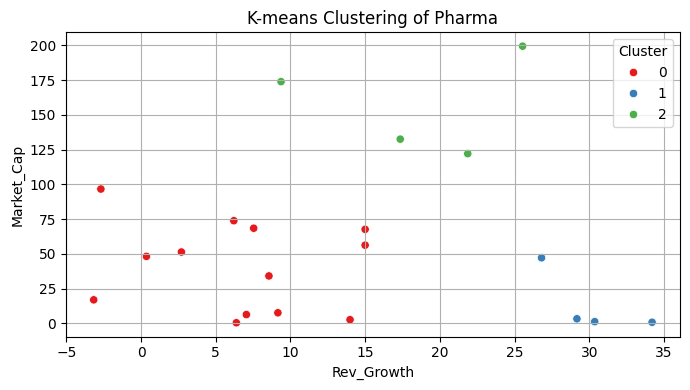

In [ ]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data = clustered_pharma, y = 'Market_Cap', x = 'Rev_Growth',
                hue = 'Cluster', palette = 'Set1')
plt.title('K-means Clustering of Pharma')
plt.ylabel('Market_Cap')
plt.xlabel('Rev_Growth')
plt.tight_layout()
plt.grid(True)
plt.show()

C) Interpret the plot in B). Specifically, comment on whether the three groups of groups tend to have different values in terms of market capitalization and revenue growth.

En la gráfica de K-means se ven tres grupos bien definidos: el Cluster 1 (azul) reúne empresas con Market Cap menor a 50 millones y un Revenue Growth mayor al 25%, es decir, compañías pequeñas pero con gran crecimiento. El Cluster 0 (rojo) incluye firmas con Market Cap entre 10 y 100 millones, cuyo crecimiento es muy variado, desde valores negativos hasta cerca del 15%, lo que refleja mayor inestabilidad. Finalmente, el Cluster 2 (verde) agrupa empresas con Market Cap superior a 100 millones y un Revenue Growth entre 8% y 25%, mostrando compañías más grandes y con un crecimiento sólido pero moderado.




---


## Question 2

A) Determine the best number of groups to use according to **K-means algorithm** using *all* predictors. That is, find the best value of *K*.

In [ ]:
#debemos usar todos los predictores y  cambiar al graficar el símbolo en lugar de hue usar marker
X2_pharma = pharma_data.filter(['Market_Cap', 'Beta',
                          'PE_Ratio', 'ROE',"ROA","Asset_Turnover","Leverage","Rev_Growth","Net_Profit_Margin"])

## Do not forget to standardize.
scaler = StandardScaler()
Xs2_pharma = scaler.fit_transform(X2_pharma)

In [ ]:
inertias = []
k_max = 11 # Maximum number of clusters to test.

for i in range(1,k_max):
    kmeans = KMeans(n_clusters=i, random_state= 301655) # Define K-means. #agregar random state - semilla
    kmeans.fit(Xs2_pharma) # Fit K-means to data estandarizada.
    inertias.append(kmeans.inertia_) # Save the inertia.

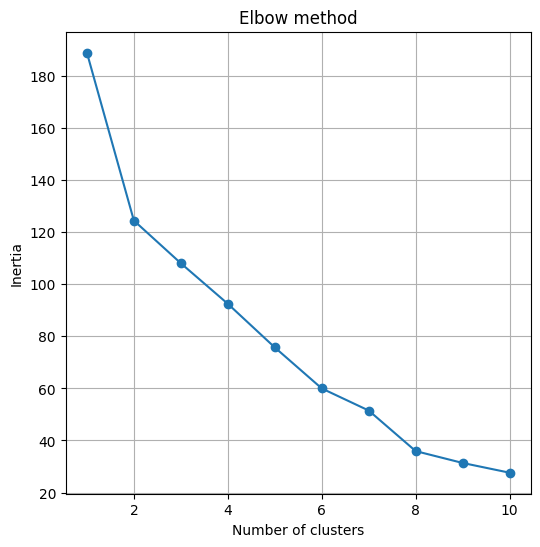

In [ ]:
plt.figure(figsize=(6, 6))
plt.plot(range(1,k_max), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

Answer: Seleccioné K = 6 porque, al aumentar el número de clústeres, la inercia disminuye de manera significativa, lo que indica que el modelo logra una mejor adaptación a los datos. Con seis grupos se obtiene una segmentación más detallada y se reduce la variabilidad dentro de cada clúster, lo que permite capturar diferencias más específicas entre las empresas


B) Using the **K-means algorithm** and the best value of *K*, create a table showing the observations that belong to each group.

In [ ]:
# Fit KMeans with 6 clusters
kmeans = KMeans(n_clusters = 6, random_state = 301655)
clusters = kmeans.fit_predict(Xs2_pharma)
clusters

array([1, 2, 1, 1, 1, 2, 1, 4, 3, 0, 5, 1, 5, 3, 5, 0, 5, 2, 1, 3, 0],
      dtype=int32)

In [ ]:
clustered2_pharma = (X2_pharma
              .assign(Cluster = clusters)
              )

clustered2_pharma

,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin,Cluster
0,68.44,0.32,24.7,26.4,11.8,0.7,0.42,7.54,16.1,1
1,7.58,0.41,82.5,12.9,5.5,0.9,0.60,9.16,5.5,2
2,6.30,0.46,20.7,14.9,7.8,0.9,0.27,7.05,11.2,1
3,67.63,0.52,21.5,27.4,15.4,0.9,0.00,15.00,18.0,1
4,47.16,0.32,20.1,21.8,7.5,0.6,0.34,26.81,12.9,1
5,16.90,1.11,27.9,3.9,1.4,0.6,0.00,-3.17,2.6,2
6,51.33,0.50,13.9,34.8,15.1,0.9,0.57,2.70,20.6,1
7,0.41,0.85,26.0,24.1,4.3,0.6,3.51,6.38,7.5,4
8,0.78,1.08,3.6,15.1,5.1,0.3,1.07,34.21,13.3,3
9,73.84,0.18,27.9,31.0,13.5,0.6,0.53,6.21,23.4,0




---


### Question 3

A) Apply the **hierarchical clustering technique** with a "Complete" linkage to detect 6 groups of observations.

In [ ]:
Clust_pharma = linkage(Xs2_pharma, method = 'complete')

In [ ]:
# Define the number of clusters
num_clusters = 6

# Compute the color threshold to form exactly 3 clusters
# Find the distance at which to cut the dendrogram
distance_threshold = Clust_pharma[-(num_clusters - 1), 2] #estudiar distancias para hacer el coloreado

B) Display the dendrogram obtained using the previous clustering technique.

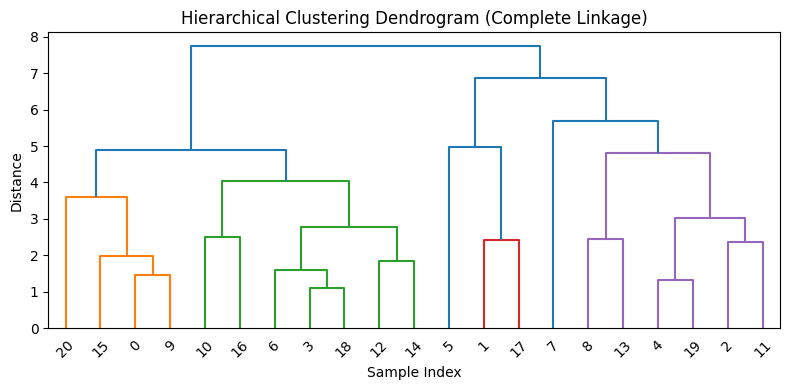

In [ ]:
plt.figure(figsize=(8, 4))
dendrogram(Clust_pharma, color_threshold = distance_threshold)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()



---


## Question 4

Using the grouping from Question 3, create a table showing the observations that belong to each group.

Cluster 1:


*   20
*   15
*   0
*   9

Cluster 2:
*   10
*   16
*   6
*   3
*   18
*   12
*   14

Cluster 3:
*   5

Cluster 4:
*   1
*   17

Cluster 5:
*   7

Cluster 6:
*   8
*   13
*   4
*   19
*   2
*   11





**Encontramos una manera de hacerlo por medio de código :)**

In [ ]:
from scipy.cluster.hierarchy import fcluster

#Añadir las obsevaciones a los clusters
clusters_3 = fcluster(Clust_pharma, t=6, criterion='maxclust')
clusters_3

#añadir los cluster a la data original
Clust_pharma_data = pharma_data.assign(Cluster = clusters_3)

for cluster_id, group in Clust_pharma_data.groupby('Cluster'):
    print(f"Cluster {cluster_id}:")
    display(group)

Cluster 1:


,Symbol,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin,Median_Recommendation,Location,Exchange,Cluster
0,ABT,Abbott Laboratories,68.44,0.32,24.7,26.4,11.8,0.7,0.42,7.54,16.1,Moderate Buy,US,NYSE,1
9,LLY,Eli Lilly and Company,73.84,0.18,27.9,31.0,13.5,0.6,0.53,6.21,23.4,Hold,US,NYSE,1
15,NVS,Novartis AG,96.65,0.19,21.6,17.9,11.2,0.5,0.06,-2.69,22.4,Hold,SWITZERLAND,NYSE,1
20,WYE,Wyeth,48.19,0.63,13.1,54.9,13.4,0.6,1.12,0.36,25.5,Hold,US,NYSE,1


Cluster 2:


,Symbol,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin,Median_Recommendation,Location,Exchange,Cluster
3,AZN,AstraZeneca PLC,67.63,0.52,21.5,27.4,15.4,0.9,0.00,15.00,18.0,Moderate Sell,UK,NYSE,2
6,BMY,Bristol-Myers Squibb Company,51.33,0.50,13.9,34.8,15.1,0.9,0.57,2.70,20.6,Moderate Sell,US,NYSE,2
10,GSK,GlaxoSmithKline plc,122.11,0.35,18.0,62.9,20.3,1.0,0.34,21.87,21.1,Hold,UK,NYSE,2
12,JNJ,Johnson & Johnson,173.93,0.46,28.4,28.6,16.3,0.9,0.10,9.37,17.9,Moderate Buy,US,NYSE,2
14,MRK,"Merck & Co., Inc.",132.56,0.46,18.9,40.6,15.0,1.1,0.28,17.35,14.1,Hold,US,NYSE,2
16,PFE,Pfizer Inc,199.47,0.65,23.6,45.6,19.2,0.8,0.16,25.54,25.2,Moderate Buy,US,NYSE,2
18,SGP,Schering-Plough Corporation,34.10,0.51,18.9,22.6,13.3,0.8,0.00,8.56,17.6,Hold,US,NYSE,2


Cluster 3:


...

,Symbol,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin,Median_Recommendation,Location,Exchange,Cluster
5,BAY,Bayer AG,16.9,1.11,27.9,3.9,1.4,0.6,0.0,-3.17,2.6,Hold,GERMANY,NYSE,4


Cluster 5:


,Symbol,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin,Median_Recommendation,Location,Exchange,Cluster
2,AHM,Amersham plc,6.30,0.46,20.7,14.9,7.8,0.9,0.27,7.05,11.2,Strong Buy,UK,NYSE,5
4,AVE,Aventis,47.16,0.32,20.1,21.8,7.5,0.6,0.34,26.81,12.9,Moderate Buy,FRANCE,NYSE,5
8,ELN,"Elan Corporation, plc",0.78,1.08,3.6,15.1,5.1,0.3,1.07,34.21,13.3,Moderate Sell,IRELAND,NYSE,5
11,IVX,IVAX Corporation,2.60,0.65,19.9,21.4,6.8,0.6,1.45,13.99,11.0,Hold,US,AMEX,5
13,MRX,Medicis Pharmaceutical Corporation,1.20,0.75,28.6,11.2,5.4,0.3,0.93,30.37,21.3,Moderate Buy,US,NYSE,5
19,WPI,"Watson Pharmaceuticals, Inc.",3.26,0.24,18.4,10.2,6.8,0.5,0.20,29.18,15.1,Moderate Sell,US,NYSE,5


Cluster 6:


,Symbol,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin,Median_Recommendation,Location,Exchange,Cluster
7,CHTT,"Chattem, Inc",0.41,0.85,26.0,24.1,4.3,0.6,3.51,6.38,7.5,Moderate Buy,US,NASDAQ,6




---


## Question 5

A) For each group created in Question 3, calculate the average value of the Market_Cap, PE_Ratio, and ROA predictors for each group. That is, calculate the average value of Market_Cap for the companies in group 1.

In [ ]:
Clust_pharma_data

,Symbol,Name,Market_Cap,Beta,PE_Ratio,ROE,ROA,Asset_Turnover,Leverage,Rev_Growth,Net_Profit_Margin,Median_Recommendation,Location,Exchange,Cluster
0,ABT,Abbott Laboratories,68.44,0.32,24.7,26.4,11.8,0.7,0.42,7.54,16.1,Moderate Buy,US,NYSE,1
1,AGN,"Allergan, Inc.",7.58,0.41,82.5,12.9,5.5,0.9,0.60,9.16,5.5,Moderate Buy,CANADA,NYSE,3
2,AHM,Amersham plc,6.30,0.46,20.7,14.9,7.8,0.9,0.27,7.05,11.2,Strong Buy,UK,NYSE,5
3,AZN,AstraZeneca PLC,67.63,0.52,21.5,27.4,15.4,0.9,0.00,15.00,18.0,Moderate Sell,UK,NYSE,2
4,AVE,Aventis,47.16,0.32,20.1,21.8,7.5,0.6,0.34,26.81,12.9,Moderate Buy,FRANCE,NYSE,5
5,BAY,Bayer AG,16.90,1.11,27.9,3.9,1.4,0.6,0.00,-3.17,2.6,Hold,GERMANY,NYSE,4
6,BMY,Bristol-Myers Squibb Company,51.33,0.50,13.9,34.8,15.1,0.9,0.57,2.70,20.6,Moderate Sell,US,NYSE,2
7,CHTT,"Chattem, Inc",0.41,0.85,26.0,24.1,4.3,0.6,3.51,6.38,7.5,Moderate Buy,US,NASDAQ,6
8,ELN,"Elan Corporation, plc",0.78,1.08,3.6,15.1,5.1,0.3,1.07,34.21,13.3,Moderate Sell,IRELAND,NYSE,5
9,LLY,Eli Lilly and Company,73.84,0.18,27.9,31.0,13.5,0.6,0.53,6.21,23.4,Hold,US,NYSE,1


In [ ]:
print("Promedios del Cluster 1")
(Clust_pharma_data
  .query("Cluster == 1")
  .filter(["Market_Cap", "PE_Ratio", "ROA"], axis = 1)
  .mean()
  .rename('Promedio') # Add this line to rename the series
)

Promedios del Cluster 1


,Promedio
Market_Cap,71.780
PE_Ratio,21.825
ROA,12.475


B) Do the same for groups 2, 3, 4, 5, and 6.

C) Repeat this entire procedure for the PE_Ratio and ROA predictors.

In [ ]:
cluster_means = Clust_pharma_data.groupby('Cluster')[['Market_Cap', 'PE_Ratio', 'ROA']].mean()
print("Promedio de las variables Market_Cap, PE_Ratio, and ROA por cluster:")
cluster_means

Promedio de las variables Market_Cap, PE_Ratio, and ROA por cluster:


,Market_Cap,PE_Ratio,ROA
Cluster,,,
1,71.780000,21.825000,12.475000
2,111.590000,20.457143,16.371429
3,31.910000,69.500000,5.600000
4,16.900000,27.900000,1.400000
5,10.216667,18.550000,6.566667
6,0.410000,26.000000,4.300000


D) Comment on the performance of the pharmaceutical groups in terms of the average values of the Market_Cap, PE_Ratio, and ROA indicators. Justify your answer.

Answer: Los grupos farmacéuticos muestran diferencias claras en sus indicadores. El Cluster 2 es el más fuerte, con el mayor Market Cap (111.59 millones) y el ROA más alto (16.37%), lo que refleja empresas grandes y rentables. El Cluster 1 también tiene buen desempeño, con un Market Cap de 71.78 millones y un ROA de 12.47%. En cambio, el Cluster 3 presenta un PE Ratio muy alto (69.5) pero un ROA bajo (5.6%), lo que indica sobrevaloración. Los Clusters 4, 5 y 6 agrupan compañías pequeñas, con Market Cap menor a 20 millones y ROA limitado, mostrando menor eficiencia


# **Problem 2**

The "Colleges_Reduced.xlsx" data file in Canvas contains a selection of public and private colleges in the U.S. that offer bachelor's degree programs. The data includes the name of the college, its state, and whether the school is public or private (Public (1)/Private (2)). Additionally, it has data on the following predictors:

* Number of applications received (# appli. rec'd)
* Number of applications accepted (# appl. accepted)
* Number of students enrolled (# new stud. enrolled)
* Number of full-time students (# FT undergrad)
* Number of part-time students (# PT undergrad)
* In-state tuition
* Out-of-state tuition
* Estimated personal cost per month for a student (estimated personal $)
* Percentage of faculty with PhDs (% fac. w/PHD)
* Student-faculty ratio (stud./fac. ratio)
* Percentage of students who graduate (Graduation rate)

Using the database, answer the following questions.

In [ ]:
#Asegurarnos que Python está leyendo de manera correcta le data base
c_data = pd.read_excel("Colleges_Reduced.xlsx")
c_data

,College Name,State,Public (1)/ Private (2),# appli. rec'd,# appl. accepted,# new stud. enrolled,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,Alaska Pacific University,AK,2,193,146,55,249,869,7560,7560,1500,76,11.9,15
1,University of Alaska Southeast,AK,1,146,117,89,492,1849,1742,5226,1162,39,9.5,39
2,Alabama Agri. & Mech. Univ.,AL,1,2817,1920,984,3958,305,1700,3400,850,53,14.3,40
3,University of Montevallo,AL,1,1351,892,570,2385,331,2220,4440,600,72,18.9,51
4,Auburn University-Main Campus,AL,1,7548,6791,3070,16262,1716,2100,6300,1908,85,16.7,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,Shepherd College,WV,2,1405,1167,557,2452,1113,2064,4694,1665,57,16.5,46
989,West Liberty State College,WV,1,1164,1062,478,2138,227,1900,4470,1210,33,16.3,60
990,West Virginia Wesleyan College,WV,2,1566,1400,483,1509,170,14200,14200,1100,58,16.4,67
991,Wheeling Jesuit College,WV,2,903,755,213,971,305,10500,10500,600,66,14.1,72


In [ ]:
c_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   College Name             993 non-null    object 
 1   State                    993 non-null    object 
 2   Public (1)/ Private (2)  993 non-null    int64  
 3   # appli. rec'd           993 non-null    int64  
 4   # appl. accepted         993 non-null    int64  
 5   # new stud. enrolled     993 non-null    int64  
 6   # FT undergrad           993 non-null    int64  
 7   # PT undergrad           993 non-null    int64  
 8   in-state tuition         993 non-null    int64  
 9   out-of-state tuition     993 non-null    int64  
 10  estim. personal $        993 non-null    int64  
 11  % fac. w/PHD             993 non-null    int64  
 12  stud./fac. ratio         993 non-null    float64
 13  Graduation rate          993 non-null    int64  
dtypes: float64(1), int64(11), 

## Question 1

A) Apply the principal components analysis using all predictors excluding university name, state, and whether the university is public or private.

In [ ]:
# Select the predictors
features = ['# appli. rec\'d', '# appl. accepted', '# new stud. enrolled', '# FT undergrad',
            '# PT undergrad', 'in-state tuition', 'out-of-state tuition',"estim. personal $","% fac. w/PHD","stud./fac. ratio","Graduation rate"]
X_c = c_data.filter(features)

# Standardize the data
scaler = StandardScaler()
Xs_c = scaler.fit_transform(X_c)

In [ ]:
pca = PCA() #DECIRLE A PYTHON QUE ESTE OBJETO VA A CONTENER ESTE MÉTODO
PCA_c = pca.fit_transform(Xs_c)

B) How many principal components are needed to explain 60% of the dispersion in the data? Justify your answer using tables displayed by the software and, if possible, formulas shown in the slides.

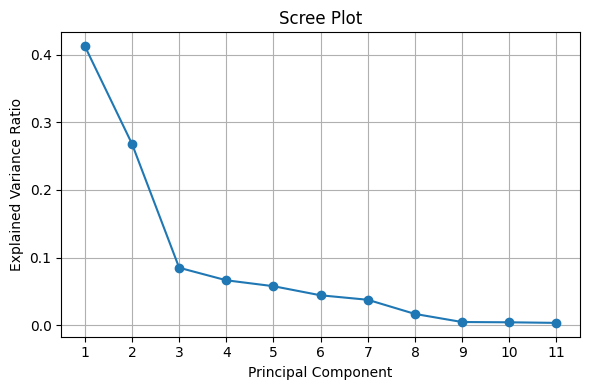

In [ ]:
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o', linestyle='-')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_var) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

Answer

Con los primeros 2 componentes es posible explicar el alrededor del 60% de la varianza. El primer componente cuenta con un 40%, mientras que el segundo un estimado del 28%; en conjunto, ambos abarcan el 68% de la dispersión, por lo que podemos concluir que el modelo es apto para usar con los datos proporcionados.

C) Construct a bi-plot in terms of the first two principal components

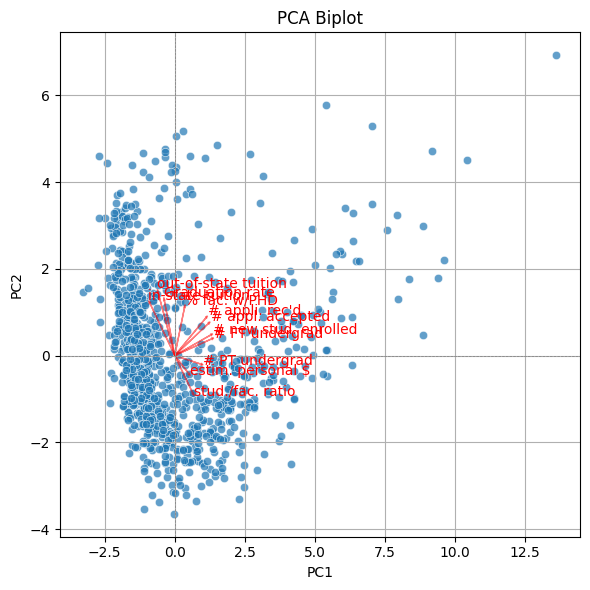

In [ ]:
# Create a DataFrame with the PCA results
pca_df = pd.DataFrame(PCA_c, columns=[f'PC{i+1}' for i in range(PCA_c.shape[1])])

# Create biplot of first two principal components
plt.figure(figsize=(6, 6))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], alpha=0.7)

# Add variable vectors
loadings = pca.components_.T[:, :2]  # loadings for PC1 and PC2
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3,
              color='red', alpha=0.5, head_width=0.05)
    plt.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, feature, color='red')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot')
plt.grid(True)
plt.tight_layout()
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.show()